In [1]:
import matplotlib

import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path

import cartopy.crs as ccrs
import pandas as pd
import lonlat_labels as label

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

data_file=PROJECT_ROOT/"data/boueguer_tesseroid_11km_1deg.csv"

df = pd.read_csv(data_file)
lon_raw = np.sort(df['lon'].unique())
lat_raw = np.sort(df['lat'].unique())
nlat = len(np.unique(lat_raw))
nlon = len(np.unique(lon_raw))

grav_grid = df.pivot(index='lat', columns='lon', values='deltaN').loc[lat_raw, lon_raw].values
topo_grid = df.pivot(index='lat', columns='lon', values='topo').loc[lat_raw, lon_raw].values
LON, LAT = np.meshgrid(lon_raw, lat_raw)
da_tesseroid=xr.DataArray(grav_grid,dims=('lat','lon'),coords={'lat': lat_raw,'lon': lon_raw})

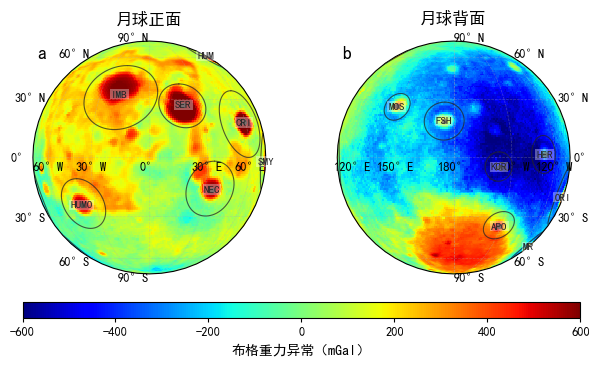

In [3]:
da=da_tesseroid
# -----------------------------
# Nature-ish + 中文风格
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

# -----------------------------
# 数据
# -----------------------------
lon = da["lon"].values
lat = da["lat"].values
Z = da.values
v = 600

# -----------------------------
# 图尺寸（更论文友好）
# -----------------------------
fig = plt.figure(figsize=(7.2, 3.6))

# ============================
# 正面
# ============================
ax1 = plt.subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax1.set_global()

pm1 = ax1.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="jet",
    vmin=-v, vmax=v
)

ax1.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5,
    alpha=0.35,
    linestyle="--"
)

ax1.set_title("月球正面", y=1.04)
add_panel_label(ax1, "a")

# ============================
# 背面
# ============================
ax2 = plt.subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax2.set_global()

pm2 = ax2.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="jet",
    vmin=-v, vmax=v
)

ax2.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5,
    alpha=0.35,
    linestyle="--"
)

ax2.set_title("月球背面", y=1.04)
add_panel_label(ax2, "b")

# -----------------------------
# 色标（更简洁）
# -----------------------------
cbar = fig.colorbar(
    pm1, ax=[ax1, ax2],
    orientation="horizontal",
    pad=0.10,
    fraction=0.06,
    aspect=35
)
cbar.set_label("布格重力异常（mGal）")
cbar.ax.tick_params(labelsize=9)

# -----------------------------
# 经纬度标签（你原逻辑）
# -----------------------------
xlocs = np.arange(-180, 180, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left")
label.add_lon_labels_on_equator(ax1, xlocs)

label.add_lat_labels_on_limb(ax2, ylocs, side="right")
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0))

# -----------------------------
# 盆地：新写法（缩写+全称）
# 图上显示缩写 abbr；题注里写全称 fullname
# -----------------------------
from plot_basins import add_basin

basins = [
    ("IMB",  "Imbrium",               33.0,  -18.0, 580),
    ("SER",  "Serenitatis",           27.0,   19.0, 370),
    ("CRI",  "Crisium",               17.5,   58.5, 530),
    ("SMY",  "Smythii",               -2.0,   87.0, 420),
    ("HUM",  "Humboldtianum",         61.0,   84.0, 300),
    ("MOS",  "Moscoviense",           26.0,  147.0, 222.5),
    ("FSH",  "Freundlich–Sharonov",   18.5,  175.0, 300),
    ("KOR",  "Korolev",               -4.5, -157.0, 220),
    ("HER",  "Hertzsprung",            1.5, -128.5, 285),
    ("ORI",  "Orientale",            -20.0,  -95.0, 465),
    ("HUMO", "Humorum",              -24.0,  -39.5, 410),
    ("NEC",  "Nectaris",             -16.0,   34.0, 430),
    ("APO",  "Apollo",               -36.0, -151.0, 252.5),
    ("MR",   "Mendel–Rydberg",       -50.0,  -94.0, 315),
]

for (abbr, fullname, lat0, lon0, r_km) in basins:
    # 这里用更克制的线宽和透明度（论文更舒服）
    add_basin(ax1, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75)
    add_basin(ax2, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75)

# -----------------------------
# 保存
# -----------------------------
fig.savefig(PROJECT_ROOT/"plotting/figure/空间域_布格重力异常.png", dpi=600, bbox_inches="tight")

plt.show()

In [4]:
data_file=PROJECT_ROOT/"data/boueguer_frenquency_11km_1deg.csv"

df = pd.read_csv(data_file)
lon_raw = np.sort(df['lon'].unique())
lat_raw = np.sort(df['lat'].unique())
nlat = len(np.unique(lat_raw))
nlon = len(np.unique(lon_raw))

grav_grid = df.pivot(index='lat', columns='lon', values='deltaN').loc[lat_raw, lon_raw].values
topo_grid  = df.pivot(index='lat', columns='lon', values='topo').loc[lat_raw, lon_raw].values
LON, LAT = np.meshgrid(lon_raw, lat_raw)
da_frenquency=xr.DataArray(grav_grid,dims=('lat','lon'),coords={'lat': lat_raw,'lon': lon_raw})

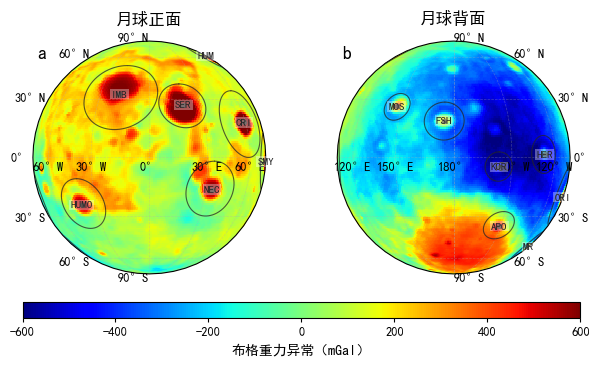

In [5]:
da=da_frenquency
# -----------------------------
# Nature-ish + 中文风格
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

# -----------------------------
# 数据
# -----------------------------
lon = da["lon"].values
lat = da["lat"].values
Z = da.values
v = 600

# -----------------------------
# 图尺寸（更论文友好）
# -----------------------------
fig = plt.figure(figsize=(7.2, 3.6))

# ============================
# 正面
# ============================
ax1 = plt.subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax1.set_global()

pm1 = ax1.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="jet",
    vmin=-v, vmax=v
)

ax1.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5,
    alpha=0.35,
    linestyle="--"
)

ax1.set_title("月球正面", y=1.04)
add_panel_label(ax1, "a")

# ============================
# 背面
# ============================
ax2 = plt.subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax2.set_global()

pm2 = ax2.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="jet",
    vmin=-v, vmax=v
)

ax2.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5,
    alpha=0.35,
    linestyle="--"
)

ax2.set_title("月球背面", y=1.04)
add_panel_label(ax2, "b")

# -----------------------------
# 色标（更简洁）
# -----------------------------
cbar = fig.colorbar(
    pm1, ax=[ax1, ax2],
    orientation="horizontal",
    pad=0.10,
    fraction=0.06,
    aspect=35
)
cbar.set_label("布格重力异常（mGal）")
cbar.ax.tick_params(labelsize=9)

# -----------------------------
# 经纬度标签（你原逻辑）
# -----------------------------
xlocs = np.arange(-180, 180, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left")
label.add_lon_labels_on_equator(ax1, xlocs)

label.add_lat_labels_on_limb(ax2, ylocs, side="right")
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0))

# -----------------------------
# 盆地：新写法（缩写+全称）
# 图上显示缩写 abbr；题注里写全称 fullname
# -----------------------------
from plot_basins import add_basin

basins = [
    ("IMB",  "Imbrium",               33.0,  -18.0, 580),
    ("SER",  "Serenitatis",           27.0,   19.0, 370),
    ("CRI",  "Crisium",               17.5,   58.5, 530),
    ("SMY",  "Smythii",               -2.0,   87.0, 420),
    ("HUM",  "Humboldtianum",         61.0,   84.0, 300),
    ("MOS",  "Moscoviense",           26.0,  147.0, 222.5),
    ("FSH",  "Freundlich–Sharonov",   18.5,  175.0, 300),
    ("KOR",  "Korolev",               -4.5, -157.0, 220),
    ("HER",  "Hertzsprung",            1.5, -128.5, 285),
    ("ORI",  "Orientale",            -20.0,  -95.0, 465),
    ("HUMO", "Humorum",              -24.0,  -39.5, 410),
    ("NEC",  "Nectaris",             -16.0,   34.0, 430),
    ("APO",  "Apollo",               -36.0, -151.0, 252.5),
    ("MR",   "Mendel–Rydberg",       -50.0,  -94.0, 315),
]

for (abbr, fullname, lat0, lon0, r_km) in basins:
    # 这里用更克制的线宽和透明度（论文更舒服）
    add_basin(ax1, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75)
    add_basin(ax2, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75)

# -----------------------------
# 保存
# -----------------------------
fig.savefig(PROJECT_ROOT/"plotting/figure/球谐域_布格重力异常.png", dpi=600, bbox_inches="tight")

plt.show()

In [6]:
da_frenquency=da_frenquency.interp_like(da_tesseroid)
da_diff = da_frenquency - da_tesseroid

In [7]:
da_diff

<xarray.DataArray (lat: 180, lon: 360)> Size: 518kB
array([[ -6.81970955,  -6.75394133,  -6.6832903 , ...,  -6.98547777,
         -6.93568184,  -6.88035888],
       [  2.73638756,   3.02557977,   3.27940009, ...,   1.71534458,
          2.07358478,   2.4167433 ],
       [  1.33927165,   1.25408176,   0.99771468, ...,   0.4564798 ,
          0.93379638,   1.23279212],
       ...,
       [-13.12273539, -13.95305484, -14.70324423, ..., -10.45988624,
        -11.34186826, -12.24116523],
       [  2.1022907 ,   2.29823509,   2.4978551 , ...,   1.52284644,
          1.71631609,   1.908849  ],
       [ -1.12836532,  -1.11186346,  -1.09635222, ...,  -1.18309149,
         -1.16404607,  -1.14578751]], shape=(180, 360))
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

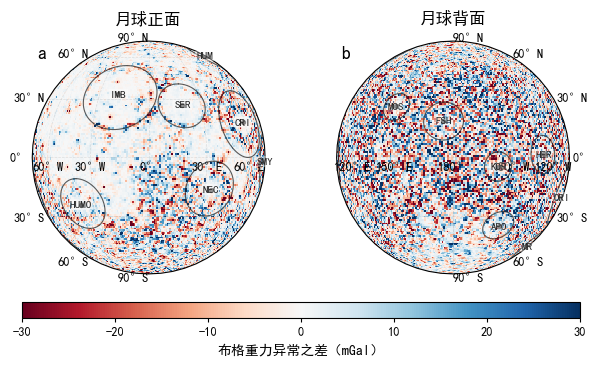

In [8]:
da=da_diff
# -----------------------------
# Nature-ish + 中文风格
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

# -----------------------------
# 数据
# -----------------------------
lon = da["lon"].values
lat = da["lat"].values
Z = da.values
v = 30

# -----------------------------
# 图尺寸（更论文友好）
# -----------------------------
fig = plt.figure(figsize=(7.2, 3.6))

# ============================
# 正面
# ============================
ax1 = plt.subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax1.set_global()

pm1 = ax1.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="RdBu",
    vmin=-v, vmax=v
)

ax1.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5,
    alpha=0.35,
    linestyle="--"
)

ax1.set_title("月球正面", y=1.04)
add_panel_label(ax1, "a")

# ============================
# 背面
# ============================
ax2 = plt.subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax2.set_global()

pm2 = ax2.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="RdBu",
    vmin=-v, vmax=v
)

ax2.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5,
    alpha=0.35,
    linestyle="--"
)

ax2.set_title("月球背面", y=1.04)
add_panel_label(ax2, "b")

# -----------------------------
# 色标（更简洁）
# -----------------------------
cbar = fig.colorbar(
    pm1, ax=[ax1, ax2],
    orientation="horizontal",
    pad=0.10,
    fraction=0.06,
    aspect=35
)
cbar.set_label("布格重力异常之差（mGal）")
cbar.ax.tick_params(labelsize=9)

# -----------------------------
# 经纬度标签（你原逻辑）
# -----------------------------
xlocs = np.arange(-180, 180, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left")
label.add_lon_labels_on_equator(ax1, xlocs)

label.add_lat_labels_on_limb(ax2, ylocs, side="right")
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0))

# -----------------------------
# 盆地：新写法（缩写+全称）
# 图上显示缩写 abbr；题注里写全称 fullname
# -----------------------------
from plot_basins import add_basin

basins = [
    ("IMB",  "Imbrium",               33.0,  -18.0, 580),
    ("SER",  "Serenitatis",           27.0,   19.0, 370),
    ("CRI",  "Crisium",               17.5,   58.5, 530),
    ("SMY",  "Smythii",               -2.0,   87.0, 420),
    ("HUM",  "Humboldtianum",         61.0,   84.0, 300),
    ("MOS",  "Moscoviense",           26.0,  147.0, 222.5),
    ("FSH",  "Freundlich–Sharonov",   18.5,  175.0, 300),
    ("KOR",  "Korolev",               -4.5, -157.0, 220),
    ("HER",  "Hertzsprung",            1.5, -128.5, 285),
    ("ORI",  "Orientale",            -20.0,  -95.0, 465),
    ("HUMO", "Humorum",              -24.0,  -39.5, 410),
    ("NEC",  "Nectaris",             -16.0,   34.0, 430),
    ("APO",  "Apollo",               -36.0, -151.0, 252.5),
    ("MR",   "Mendel–Rydberg",       -50.0,  -94.0, 315),
]

for (abbr, fullname, lat0, lon0, r_km) in basins:
    # 这里用更克制的线宽和透明度（论文更舒服）
    add_basin(ax1, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75)
    add_basin(ax2, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75)

# -----------------------------
# 保存
# -----------------------------
fig.savefig(PROJECT_ROOT/"plotting/figure/两种计算方法的布格重力异常差.png", dpi=600, bbox_inches="tight")

plt.show()

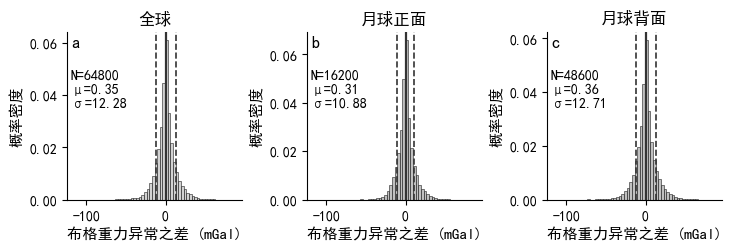

Saved: e:\Moho\all_code_for_github\plotting\figure\两种计算方法的布格重力异常之差_直方图.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt

Z=da_diff.values
# -----------------------------
# Nature-ish 全局风格设置
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],  # Arial优先；没装就用DejaVu；中文备用SimHei
    "axes.unicode_minus": False,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# -----------------------------
# 分组数据（你的原逻辑）
# -----------------------------
Z_all = Z.ravel()
Z_all = Z_all[np.isfinite(Z_all)]

Lon2d = np.broadcast_to(lon[None, :], Z.shape)

near_mask = (Lon2d >= -90) & (Lon2d <= 90)
far_mask = ~near_mask

Z_near = Z[near_mask]
Z_far  = Z[far_mask]
Z_near = Z_near[np.isfinite(Z_near)]
Z_far  = Z_far[np.isfinite(Z_far)]

far_west_mask = (Lon2d >= -180) & (Lon2d <= -90)
far_east_mask = (Lon2d >= 90) & (Lon2d < 180)

Z_far_west = Z[far_west_mask]
Z_far_east = Z[far_east_mask]
Z_far_west = Z_far_west[np.isfinite(Z_far_west)]
Z_far_east = Z_far_east[np.isfinite(Z_far_east)]

# -----------------------------
# 统一 bins（可比）
# -----------------------------
bins = 60
vmin = np.nanmin(Z_all)
vmax = np.nanmax(Z_all)
bin_edges = np.linspace(vmin, vmax, bins + 1)

# -----------------------------
# 小工具：面板标注 a/b/c...
# -----------------------------
def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=12, fontweight="bold"
    )

# -----------------------------
# 绘图函数（Nature-ish）
# -----------------------------
def plot_hist(ax, data, title, hist_color="0.6", line_color="0.2"):
    mu = np.mean(data)
    sigma = np.std(data)

    # 归一化直方图（概率密度）
    ax.hist(
        data,
        bins=bin_edges,
        density=True,
        color=hist_color,
        alpha=0.70,
        edgecolor="0.15",
        linewidth=0.6,
    )

    # μ 实线；±σ 虚线
    ax.axvline(mu, color=line_color, linewidth=1.6, linestyle="-")
    ax.axvline(mu - sigma, color=line_color, linewidth=1.2, linestyle="--")
    ax.axvline(mu + sigma, color=line_color, linewidth=1.2, linestyle="--")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("布格重力异常之差 (mGal)", fontsize=11)
    ax.set_ylabel("概率密度", fontsize=11)

    # 更干净：去掉上/右边框（Nature 常见）
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 文字标注（别太大，避免抢画面）
    ax.text(
        0.02, 0.78,
        f"N={data.size}\nμ={mu:.2f}\nσ={sigma:.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10
    )

# -----------------------------
# Figure 1：3张（全局/正/背）
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.4), constrained_layout=True)
# Nature 单栏宽常见 85 mm ≈ 3.35 in；双栏 ~180 mm ≈ 7.1 in
# 这里用 7.2 in 做横向三联图，偏双栏宽

plot_hist(axes[0], Z_all,  "全球",   hist_color="0.75")
plot_hist(axes[1], Z_near, "月球正面", hist_color="0.65")
plot_hist(axes[2], Z_far,  "月球背面",  hist_color="0.65")

add_panel_label(axes[0], "a")
add_panel_label(axes[1], "b")
add_panel_label(axes[2], "c")

out_png = PROJECT_ROOT/"plotting/figure/两种计算方法的布格重力异常之差_直方图.png"
#out_pdf = PROJECT_ROOT/"plotting/figure/两种计算方法的布格重力异常之差_直方图.pdf"

fig.savefig(out_png, dpi=600)              # Nature 常见要求高分辨率
#fig.savefig(out_pdf, dpi=600, transparent=True)
plt.show()
print(f"Saved: {out_png}")
#print(f"Saved: {out_pdf}")


In [10]:
x=topo_grid.ravel()
y=Z.ravel()

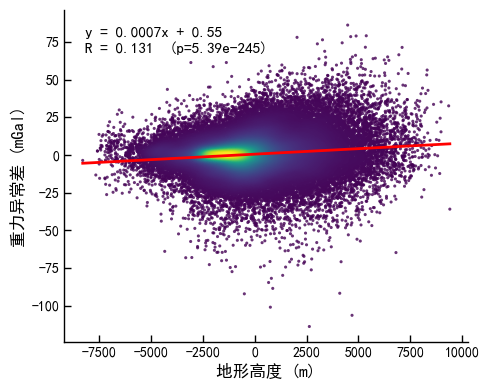

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy import stats

# 去掉 NaN
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# 线性拟合
k, b = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 300)
ys = k*xs + b

# 相关系数
r, p = stats.pearsonr(x, y)

# ---- 点密度（让散点更好看）----
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 按密度排序（避免遮挡）
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

fig, ax = plt.subplots(figsize=(5,4))

sc = ax.scatter(
    x, y,
    c=z,
    s=5,
    cmap="viridis",
    alpha=0.8,
    edgecolors="none"
)

# 拟合线
ax.plot(xs, ys, color="red", linewidth=2)

# 拟合公式
text = f"y = {k:.4f}x + {b:.2f}\nR = {r:.3f}  (p={p:.2e})"
ax.text(
    0.05, 0.95,
    text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top'
)

# 坐标轴
ax.set_xlabel("地形高度 (m)", fontsize=12)
ax.set_ylabel("重力异常差 (mGal)", fontsize=12)

# Nature 风格
ax.tick_params(direction='in', length=5, width=1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.tight_layout()

# 保存
plt.savefig(PROJECT_ROOT/"plotting/figure/两种方法计算的布格重力异常差与地形的关系.png", dpi=600)
#plt.savefig(PROJECT_ROOT/"plotting/figure/两种方法计算的布格重力异常差与地形的关系.pdf", dpi=600, transparent=True)

plt.show()

In [12]:
win = 5
pad = win // 2

# 左右各拼接 pad 个格点
left = da.isel(lon=slice(-pad, None))
right = da.isel(lon=slice(0, pad))

# 调整经度坐标，避免重复
left = left.assign_coords(lon=left.lon - 360)
right = right.assign_coords(lon=right.lon + 360)

da_wrap = xr.concat([left, da, right], dim="lon")

# 滑窗标准差
std_wrap = da_wrap.rolling(lat=win, lon=win, center=True).std()

# 裁回原始区域
std = std_wrap.sel(lon=da.lon)

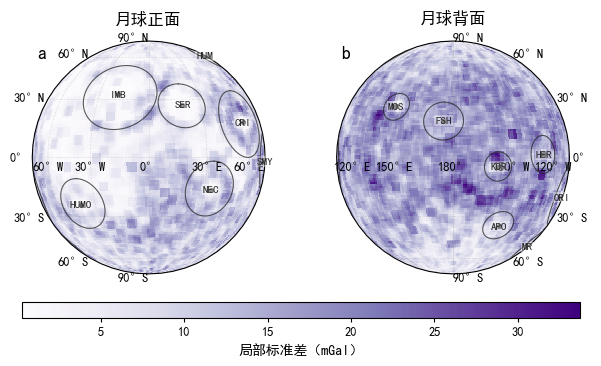

In [13]:
da=std
topo = topo_grid
neg_levels = np.arange(-8000, 0, 1000)
pos_levels = np.arange(1000, 8001, 1000)
# -----------------------------
# Nature-ish + 中文风格
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

# -----------------------------
# 数据
# -----------------------------
lon = da["lon"].values
lat = da["lat"].values
Z = da.values
v = 30

# -----------------------------
# 图尺寸（更论文友好）
# -----------------------------
fig = plt.figure(figsize=(7.2, 3.6))

# ============================
# 正面
# ============================
ax1 = plt.subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax1.set_global()

pm1 = ax1.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="Purples",
    #vmin=-v, vmax=v
)

ax1.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5,
    alpha=0.35,
    linestyle="--"
)

ax1.set_title("月球正面", y=1.04)
add_panel_label(ax1, "a")

# ============================
# 背面
# ============================
ax2 = plt.subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax2.set_global()

pm2 = ax2.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="Purples",
    #vmin=-v, vmax=v
)

ax2.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5,
    alpha=0.35,
    linestyle="--"
)

ax2.set_title("月球背面", y=1.04)
add_panel_label(ax2, "b")

# -----------------------------
# 色标（更简洁）
# -----------------------------
cbar = fig.colorbar(
    pm1, ax=[ax1, ax2],
    orientation="horizontal",
    pad=0.10,
    fraction=0.06,
    aspect=35
)
cbar.set_label("局部标准差（mGal）")
cbar.ax.tick_params(labelsize=9)

# -----------------------------
# 经纬度标签（你原逻辑）
# -----------------------------
xlocs = np.arange(-180, 180, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left")
label.add_lon_labels_on_equator(ax1, xlocs)

label.add_lat_labels_on_limb(ax2, ylocs, side="right")
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0))

# -----------------------------
# 盆地：新写法（缩写+全称）
# 图上显示缩写 abbr；题注里写全称 fullname
# -----------------------------
from plot_basins import add_basin

basins = [
    ("IMB",  "Imbrium",               33.0,  -18.0, 580),
    ("SER",  "Serenitatis",           27.0,   19.0, 370),
    ("CRI",  "Crisium",               17.5,   58.5, 530),
    ("SMY",  "Smythii",               -2.0,   87.0, 420),
    ("HUM",  "Humboldtianum",         61.0,   84.0, 300),
    ("MOS",  "Moscoviense",           26.0,  147.0, 222.5),
    ("FSH",  "Freundlich–Sharonov",   18.5,  175.0, 300),
    ("KOR",  "Korolev",               -4.5, -157.0, 220),
    ("HER",  "Hertzsprung",            1.5, -128.5, 285),
    ("ORI",  "Orientale",            -20.0,  -95.0, 465),
    ("HUMO", "Humorum",              -24.0,  -39.5, 410),
    ("NEC",  "Nectaris",             -16.0,   34.0, 430),
    ("APO",  "Apollo",               -36.0, -151.0, 252.5),
    ("MR",   "Mendel–Rydberg",       -50.0,  -94.0, 315),
]

for (abbr, fullname, lat0, lon0, r_km) in basins:
    # 这里用更克制的线宽和透明度（论文更舒服）
    add_basin(ax1, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75)
    add_basin(ax2, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75)

# -----------------------------
# 保存
# -----------------------------
fig.savefig(PROJECT_ROOT/"plotting/figure/两种计算方法的布格重力异常之差_局部标准差.png", dpi=600, bbox_inches="tight")

plt.show()

In [14]:
y=Z.ravel()

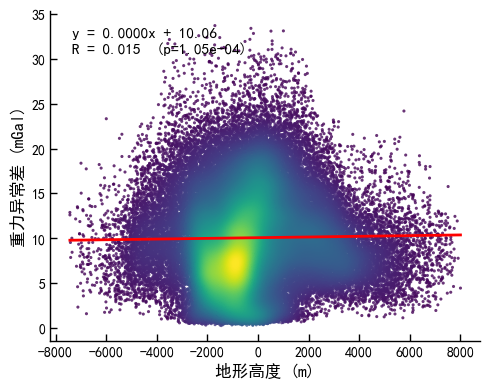

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy import stats

# 去掉 NaN
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# 线性拟合
k, b = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 300)
ys = k*xs + b

# 相关系数
r, p = stats.pearsonr(x, y)

# ---- 点密度（让散点更好看）----
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# 按密度排序（避免遮挡）
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

fig, ax = plt.subplots(figsize=(5,4))

sc = ax.scatter(
    x, y,
    c=z,
    s=5,
    cmap="viridis",
    alpha=0.8,
    edgecolors="none"
)

# 拟合线
ax.plot(xs, ys, color="red", linewidth=2)

# 拟合公式
text = f"y = {k:.4f}x + {b:.2f}\nR = {r:.3f}  (p={p:.2e})"
ax.text(
    0.05, 0.95,
    text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top'
)

# 坐标轴
ax.set_xlabel("地形高度 (m)", fontsize=12)
ax.set_ylabel("重力异常差 (mGal)", fontsize=12)

# Nature 风格
ax.tick_params(direction='in', length=5, width=1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(1)

plt.tight_layout()

# 保存
plt.savefig(PROJECT_ROOT/"plotting/figure/局部标准差与地形起伏.png", dpi=600)

plt.show()